# Predicting cell types from Single Cell RNA-Seq

In [10]:
!pip install scanpy[leiden] anndata seaborn scikit-learn igraph 

Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached https://download.pytorch.org/whl/sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached https://download.pytorch.org/whl/cu126/nvidia_cuda_nvrtc_cu12-12.6.77-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached https://download.pytorch.org/whl/cu126/nvidia_cuda_runtime_cu12-12.6.77-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.5 kB)
  Using cached https://download.pytorch.org/whl/cu126/nvidia_cuda_cupti_cu12-12.6.80-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.6 kB)
  Using cached https://download.pytorch.org/whl/nvidia_cudnn_cu12-9.10.2.21-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached https://download.pytorch.org/whl/cu126/nvidia_cublas_cu12-12.6.4.1-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.5 kB)
  Using cached https://download.pytorch.org/whl/cu126/nvidia_cufft_cu12-11.3.0.4-py3-none-manylinux2014_

## Package imports

In [3]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import scanpy as sc

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_score
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim

seed=2
np.random.seed(seed)
torch.manual_seed(seed)

In [ ]:
folders = [
    'models/logistic_regression',
    'models/random_forest',
    'models/svm',
    'models/xgboost',
    'models/mlp',
    'src',
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

## Load the dataset

In [19]:
try:
    adata = sc.read_h5ad('data/pbmc3k_raw.h5ad')
    print("Loaded from local file")
except FileNotFoundError:
    print("Local file not found, downloading...")
    adata = sc.datasets.pbmc3k()
    adata.write('data/raw/pbmc3k_raw.h5ad')

print(adata)

# Store the original full dataset in adata_full before HVG subsetting
adata_full = adata.raw.to_adata() if adata.raw is not None else adata.copy()

Loaded from local file
AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


## Data Preprocessing

In [20]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)
adata.write('data/adata_hvg.h5ad')
print(f"Saved HVG-filtered data to data/adata_hvg.h5ad")

adata = sc.read_h5ad('data/adata_hvg.h5ad')
print(f"Loaded HVG data: {adata.shape}")

sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)

Saved HVG-filtered data to data/adata_hvg.h5ad
Loaded HVG data: (2700, 2000)


# Unsupervised learning


## Leiden clustering

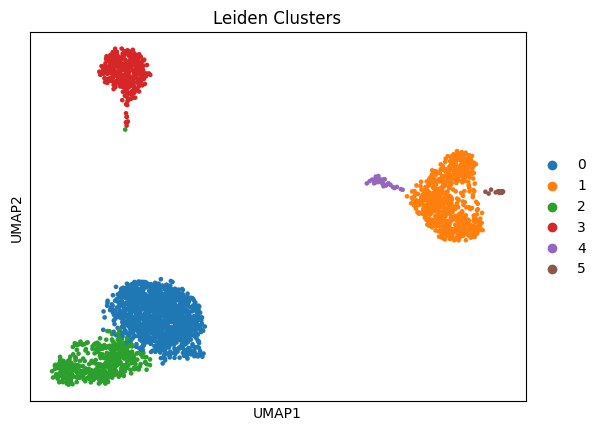

In [21]:
sc.tl.leiden(adata, resolution=0.5)
sc.pl.umap(adata, color=['leiden'], title='Leiden Clusters')

## Annotate cell types

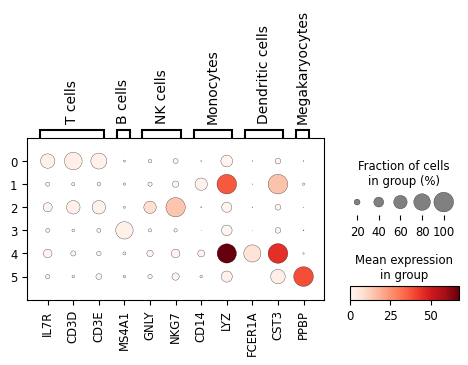

In [22]:
marker_genes = {
    "T cells": ["IL7R", "CD3D", "CD3E"],
    "B cells": ["MS4A1"],
    "NK cells": ["GNLY", "NKG7"],
    "Monocytes": ["CD14", "LYZ"],
    "Dendritic cells": ["FCER1A", "CST3"],
    "Megakaryocytes": ["PPBP"],
}

# Use full data for dotplot
# Ensure adata_full has the same cell indices as adata
adata_full.obs['leiden'] = adata.obs['leiden'].copy()
sc.pl.dotplot(adata_full, marker_genes, groupby='leiden')

In [7]:
# sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
# sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)


Cell type distribution:
cell_type
T cells                      1200
Monocytes                     651
NK cells                      443
B cells                       355
Monocytes/Dendritic cells      36
Megakaryocytes                 15
Unknown                         0
Name: count, dtype: int64


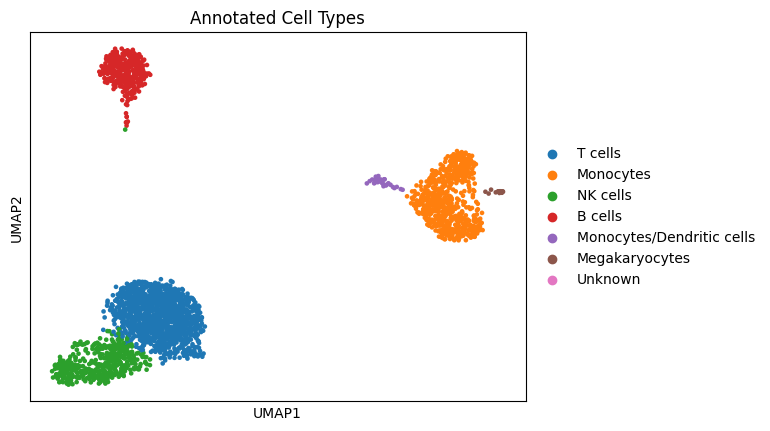

In [23]:
cluster2celltype = {
    '0': 'T cells',
    '1': 'Monocytes',
    '2': 'NK cells',
    '3': 'B cells',
    '4': 'Monocytes/Dendritic cells',
    '5': 'Megakaryocytes'
}
adata.obs['cell_type'] = adata.obs['leiden'].map(cluster2celltype)
adata.obs['cell_type'] = adata.obs['cell_type'].astype('category').cat.add_categories(["Unknown"]).fillna("Unknown")

print("Cell type distribution:")
print(adata.obs['cell_type'].value_counts())

sc.pl.umap(adata, color='cell_type', title='Annotated Cell Types')

## K-means clustering

=== K-means vs. Leiden Comparison ===
Adjusted Rand Index (ARI): 0.895
Normalized Mutual Information (NMI): 0.871
Homogeneity: 0.906


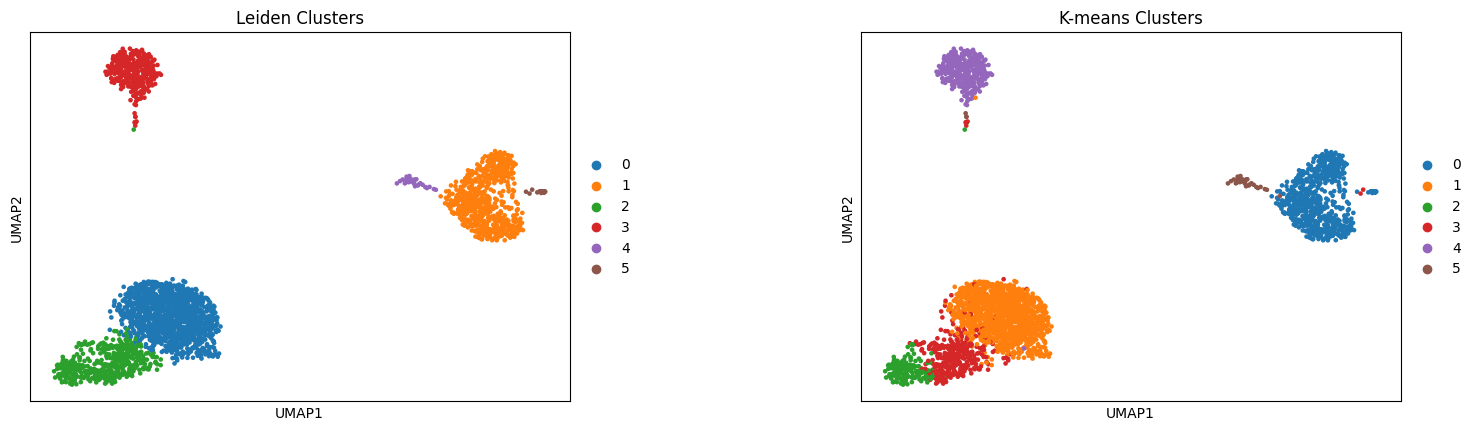

In [17]:
# Run K-means on PCA space
X_pca = adata.obsm['X_pca']
n_clusters = adata.obs['leiden'].nunique()  # match Leiden cluster count for fairness
kmeans = KMeans(n_clusters=n_clusters, random_state=1)
adata.obs['kmeans'] = kmeans.fit_predict(X_pca).astype(str)

# Compare clustering results
ari = adjusted_rand_score(adata.obs['leiden'], adata.obs['kmeans'])
nmi = normalized_mutual_info_score(adata.obs['leiden'], adata.obs['kmeans'])
hom = homogeneity_score(adata.obs['leiden'], adata.obs['kmeans'])

print("=== K-means vs. Leiden Comparison ===")
print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print(f"Normalized Mutual Information (NMI): {nmi:.3f}")
print(f"Homogeneity: {hom:.3f}")

# Visualization
sc.pl.umap(
    adata,
    color=['leiden', 'kmeans'],
    wspace=0.4,
    title=['Leiden Clusters', 'K-means Clusters']
)

## Hierarchical clustering

=== Hierarchical vs. Leiden Comparison ===
Adjusted Rand Index (ARI): 0.888
Normalized Mutual Information (NMI): 0.858
Homogeneity: 0.878


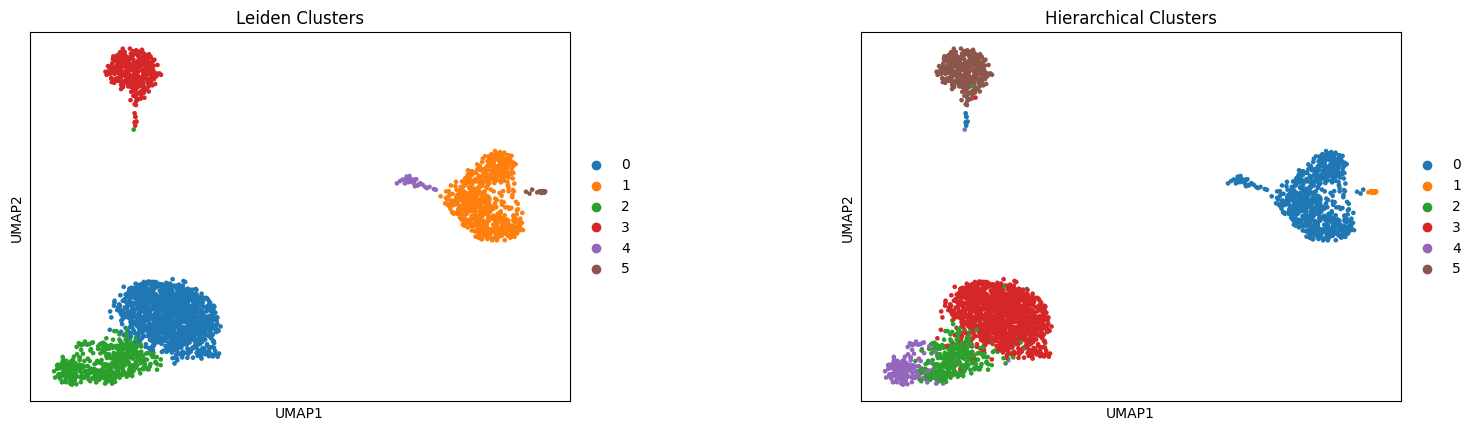

In [18]:
n_clusters = adata.obs['leiden'].nunique()  # same cluster count as Leiden
agg = AgglomerativeClustering(n_clusters=n_clusters)
adata.obs['hierarchical'] = agg.fit_predict(X_pca).astype(str)

# Compare clustering results
ari_h = adjusted_rand_score(adata.obs['leiden'], adata.obs['hierarchical'])
nmi_h = normalized_mutual_info_score(adata.obs['leiden'], adata.obs['hierarchical'])
hom_h = homogeneity_score(adata.obs['leiden'], adata.obs['hierarchical'])

print("=== Hierarchical vs. Leiden Comparison ===")
print(f"Adjusted Rand Index (ARI): {ari_h:.3f}")
print(f"Normalized Mutual Information (NMI): {nmi_h:.3f}")
print(f"Homogeneity: {hom_h:.3f}")

# Visualization
sc.pl.umap(
    adata,
    color=['leiden', 'hierarchical'],
    wspace=0.4,
    title=['Leiden Clusters', 'Hierarchical Clusters']
)

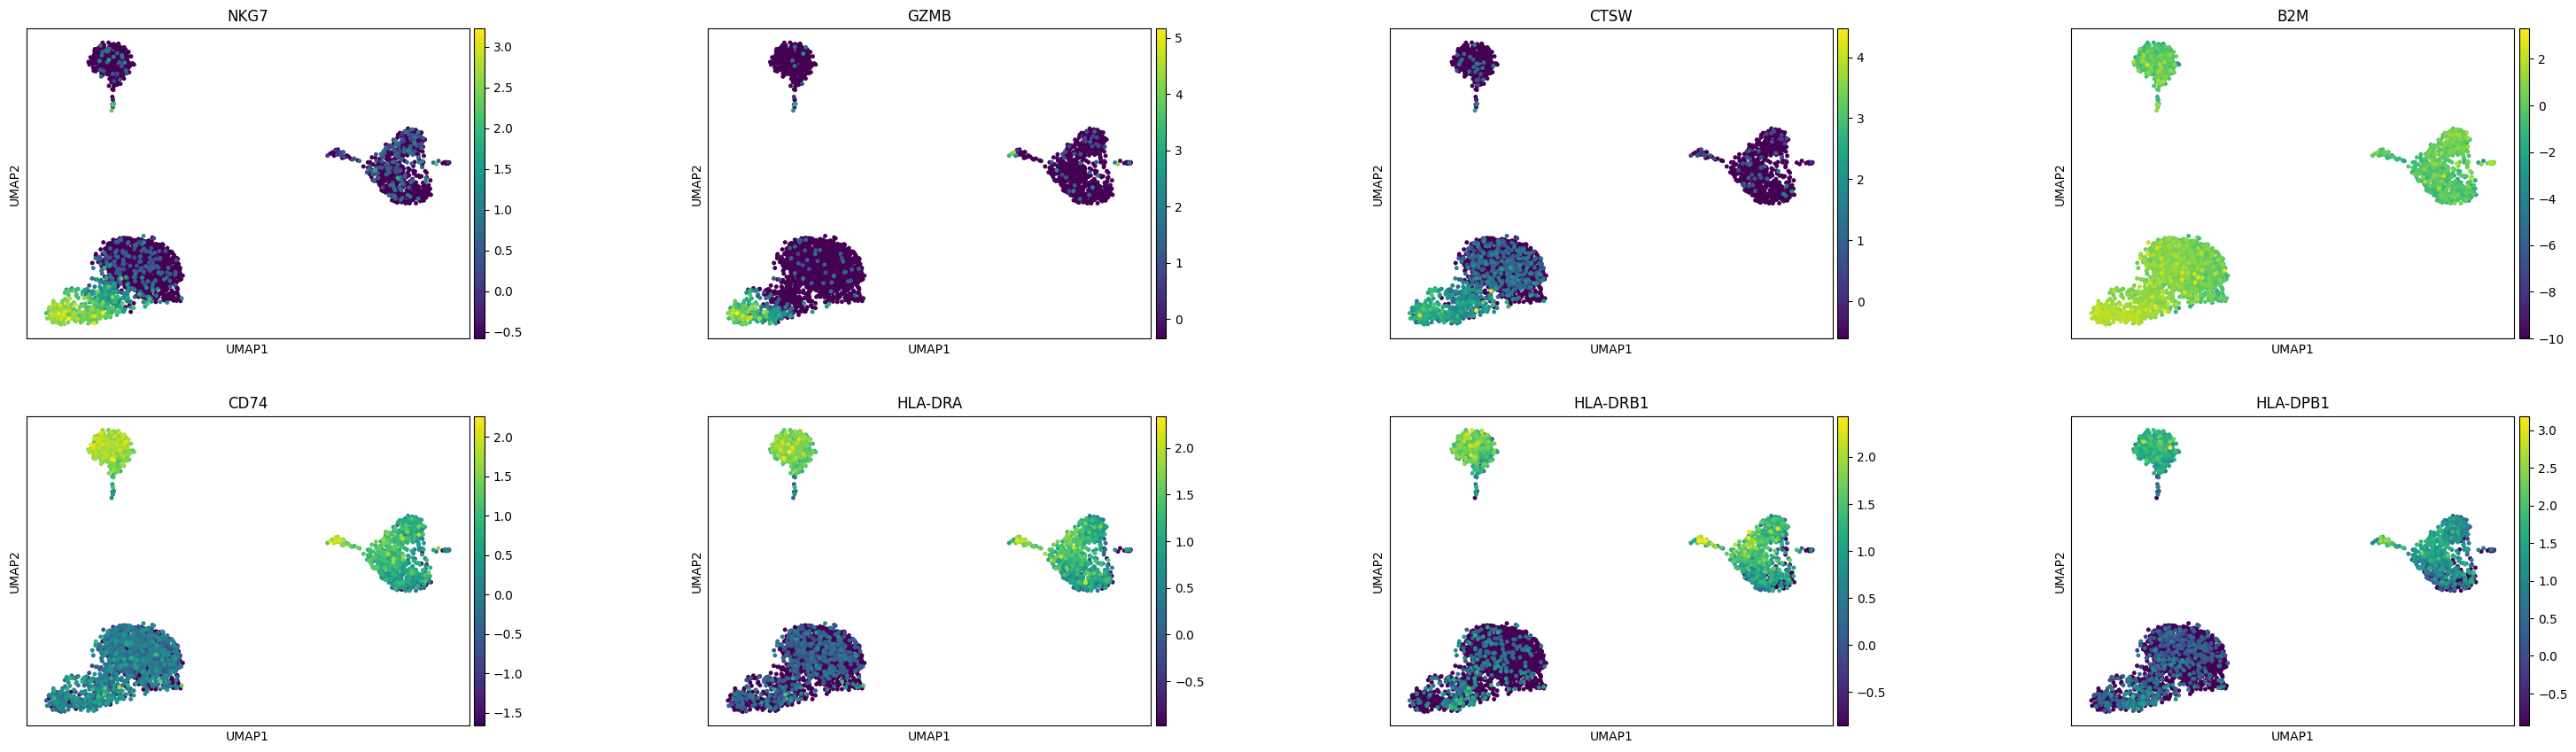

In [20]:
clusters_of_interest = ['2','4']  # K-means subcluster labels within Leiden 2
adata_sub = adata[adata.obs['kmeans'].isin(clusters_of_interest)].copy()
adata_sub.obs['kmeans'] = adata_sub.obs['kmeans'].cat.remove_unused_categories()

# Differential expression
sc.tl.rank_genes_groups(adata_sub, groupby='kmeans', method='wilcoxon')

# Extract top 4 genes for each subcluster
top_genes_cluster0 = sc.get.rank_genes_groups_df(adata_sub, group=adata_sub.obs['kmeans'].cat.categories[0])['names'].head(4).tolist()
top_genes_cluster1 = sc.get.rank_genes_groups_df(adata_sub, group=adata_sub.obs['kmeans'].cat.categories[1])['names'].head(4).tolist()

# Combine for plotting
genes_to_plot = top_genes_cluster0 + top_genes_cluster1

# UMAP plot showing expression of top DE genes
sc.pl.umap(adata, color=genes_to_plot, cmap='viridis', size=50, wspace=0.4)

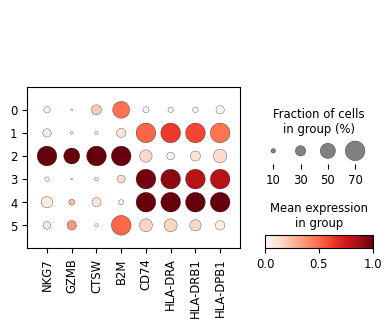

In [21]:
sc.pl.dotplot(adata, var_names=genes_to_plot, groupby='leiden', standard_scale='var', dot_max=0.7)

# Supervised learning

## Prepare data for supervised machine learning

In [32]:
X = adata.X
y = adata.obs['cell_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seed
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

In [25]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var['highly_variable']]
print(adata.shape)

(2700, 2000)


## Logistic Regression

In [ ]:
param_grid = {
    'C': [0.1, 1, 10],
    'l1_ratio': [0.2, 0.5, 0.8],
}

logreg = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=500,
    class_weight='balanced',
    random_state=seed
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

grid = GridSearchCV(logreg, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

# Evaluate on test set
best_logreg = grid.best_estimator_
y_pred = best_logreg.predict(X_test_scaled)

print("=== Logistic Regression (Elastic Net) ===")
print(classification_report(y_test, y_pred))

balanced_acc = balanced_accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
print("Balanced accuracy:", balanced_acc)
print("Weighted F1:", f1_weighted)

# Save model and scaler
joblib.dump(best_logreg, "models/logistic_regression/logreg_model_best.pkl")
print("Logistic regression model saved successfully!")

cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test)).plot(cmap=plt.cm.Blues)
plt.xticks(rotation=90)
plt.title("Elastic Net Logistic Regression Confusion Matrix")
plt.show()

Fitting 5 folds for each of 9 candidates, totalling 45 fits


In [ ]:
# Define SVM and parameter grid
svm = SVC(
      kernel='rbf',
      class_weight='balanced',
      decision_function_shape='ovr',
      probability=True,
      random_state=seed)

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# Grid search
grid_svm = GridSearchCV(svm, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid_svm.fit(X_train_scaled, y_train)

# 4. Best estimator
svm_best = grid_svm.best_estimator_
print("Best hyperparameters:", grid_svm.best_params_)
print("Best CV score:", grid_svm.best_score_)

# Predict on test set
y_pred_svm = svm_best.predict(X_test_scaled)

# Evaluation
print("=== SVM Classification Report ===")
print(classification_report(y_test, y_pred_svm))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_svm))
print("Weighted F1-score:", f1_score(y_test, y_pred_svm, average='weighted'))

joblib.dump(svm_best, "models/svm/svm_model_best_ovr.pkl")

print("SVM model saved successfully!")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm, labels=np.unique(y_test))
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test))
disp.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.xticks(rotation=90)
plt.title("SVM Confusion Matrix")
plt.show()

Fitting 5 folds for each of 6 candidates, totalling 30 fits


Best hyperparameters: {'C': 10, 'gamma': 'scale'}
Best CV score: 0.962037037037037
=== SVM Classification Report ===
                           precision    recall  f1-score   support

                  B cells       0.96      1.00      0.98        71
           Megakaryocytes       0.00      0.00      0.00         3
                Monocytes       0.97      1.00      0.98       130
Monocytes/Dendritic cells       1.00      0.29      0.44         7
                 NK cells       0.95      0.94      0.95        89
                  T cells       0.98      0.99      0.98       240

                 accuracy                           0.97       540
                macro avg       0.81      0.70      0.72       540
             weighted avg       0.97      0.97      0.97       540

Balanced accuracy: 0.7028390850722311
Weighted F1-score: 0.9651178192698753


FileNotFoundError: [Errno 2] No such file or directory: 'model/svm/svm_model_best_ovr.pkl'

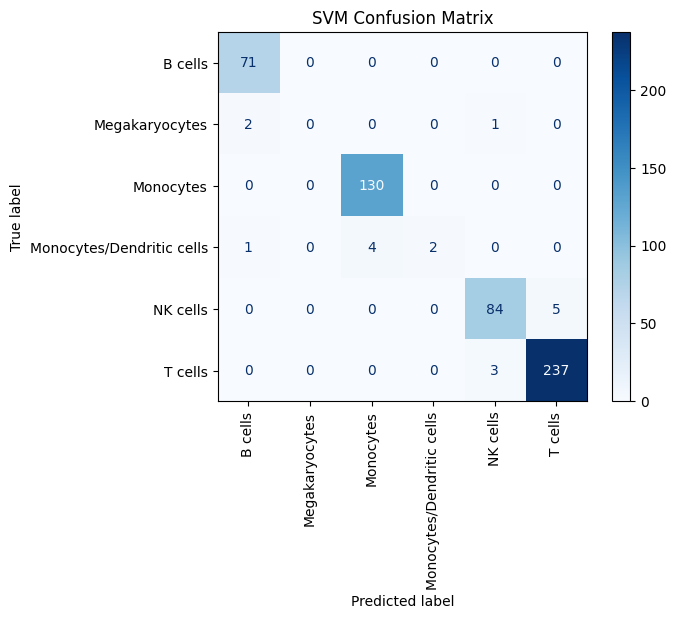

In [67]:
svm_best = joblib.load("models/svm/svm_model_best.pkl")
scaler_loaded = joblib.load("models/scaler.pkl")

X_scaled = scaler_loaded.transform(X_test)
y_pred_svm = svm_best.predict(X_new_scaled)

cm = confusion_matrix(y_test, y_pred_svm, labels=np.unique(y_test))
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test))
disp.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.xticks(rotation=90)
plt.title("SVM Confusion Matrix")
plt.show()

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Best CV score: 0.975925925925926
=== XGBoost Classification Report ===
                           precision    recall  f1-score   support

                  B cells       1.00      0.97      0.99        71
           Megakaryocytes       1.00      0.33      0.50         3
                Monocytes       0.99      0.99      0.99       130
Monocytes/Dendritic cells       0.88      1.00      0.93         7
                 NK cells       0.86      0.93      0.90        89
                  T cells       0.97      0.95      0.96       240

                 accuracy                           0.96       540
                macro avg       0.95      0.86      0.88       540
             weighted avg       0.96      0.96      0.96       540

Balanced accuracy: 0.8640371579810178
Weighted F1-score: 0.9588942163451967


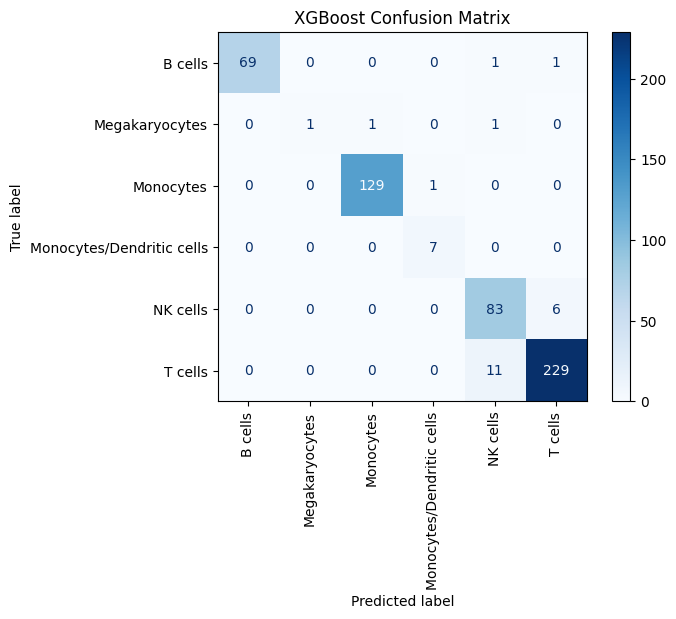

XGBoost model and scaler saved successfully!


In [ ]:
# Scale features
scaler_xgb = StandardScaler()
X_train_scaled = scaler_xgb.fit_transform(X_train)
X_test_scaled = scaler_xgb.transform(X_test)

# Encode labels to integers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Define XGBoost classifier and parameter grid
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=seed
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# Grid search
grid_xgb = GridSearchCV(xgb, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid_xgb.fit(X_train_scaled, y_train_encoded)

# Best estimator
xgb_best = grid_xgb.best_estimator_
print("Best hyperparameters:", grid_xgb.best_params_)
print("Best CV score:", grid_xgb.best_score_)

# Predict on test set
y_pred_encoded = xgb_best.predict(X_test_scaled)
y_pred_xgb = le.inverse_transform(y_pred_encoded)

# Evaluation
print("=== XGBoost Classification Report ===")
print(classification_report(y_test, y_pred_xgb))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_xgb))
print("Weighted F1-score:", f1_score(y_test, y_pred_xgb, average='weighted'))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb, labels=np.unique(y_test))
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test))
disp.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.xticks(rotation=90)
plt.title("XGBoost Confusion Matrix")
plt.show()

# Save model
joblib.dump(xgb_best, "models/xgboost/xgb_model_best.pkl")
print("XGBoost model saved successfully!")

In [ ]:
xgb_loaded = joblib.load("models/xgb/xgb_model_best.pkl")
scaler_loaded = joblib.load("models/scaler.pkl")

X_new_scaled = scaler_loaded.transform(X_test)
y_pred_new = svm_loaded.predict(X_new_scaled)

cm = confusion_matrix(y_test, y_pred_svm, labels=np.unique(y_test))
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test))
disp.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.xticks(rotation=90)
plt.title("SVM Confusion Matrix")
plt.show()

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best hyperparameters: {'max_depth': 5, 'n_estimators': 200}
Best CV score: 0.9745370370370372
=== Random Forest Classification Report ===
                           precision    recall  f1-score   support

                  B cells       1.00      0.97      0.99        71
           Megakaryocytes       1.00      0.67      0.80         3
                Monocytes       1.00      1.00      1.00       130
Monocytes/Dendritic cells       1.00      1.00      1.00         7
                 NK cells       0.87      0.94      0.90        89
                  T cells       0.97      0.95      0.96       240

                 accuracy                           0.96       540
                macro avg       0.97      0.92      0.94       540
             weighted avg       0.97      0.96      0.97       540

Balanced accuracy: 0.9227474239946546
Weighted F1-score: 0.9651543284735136


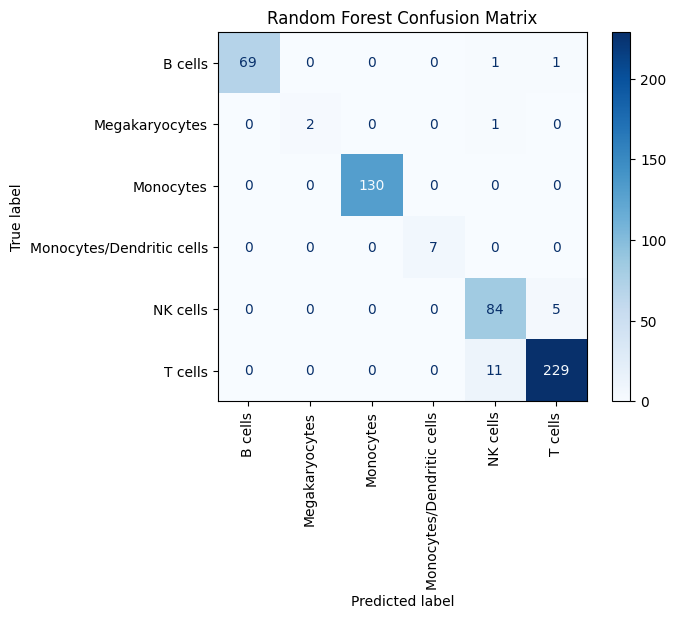

Random Forest model saved successfully!


In [33]:
# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 20, 200],
}

# Create Random Forest classifier
rf = RandomForestClassifier(class_weight='balanced', random_state=seed)

# Stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# Grid search for best hyperparameters
grid_rf = GridSearchCV(rf, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid_rf.fit(X_train_scaled, y_train)

# Best model
best_rf = grid_rf.best_estimator_
print("Best hyperparameters:", grid_rf.best_params_)
print("Best CV score:", grid_rf.best_score_)

# Predictions on test set
y_pred_rf = best_rf.predict(X_test_scaled)

# Classification report and weighted metrics
print("=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_rf))
print("Weighted F1-score:", f1_score(y_test, y_pred_rf, average='weighted'))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf, labels=np.unique(y_test))
ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test)).plot(cmap=plt.cm.Blues)
plt.xticks(rotation=90)
plt.title("Random Forest Confusion Matrix")
plt.show()

# Save model and scaler
joblib.dump(xgb_best, "models/random_forest/random_forest_model_best.pkl")
print("Random Forest model saved successfully!")

In [34]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=seed
)

# Encode labels
cell_types = np.unique(y_train)
label2idx = {label: i for i, label in enumerate(cell_types)}
y_train_idx = np.array([label2idx[lab] for lab in y_train_sub])
y_val_idx = np.array([label2idx[lab] for lab in y_val])
y_test_idx = np.array([label2idx[lab] for lab in y_test])

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_sub, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_idx, dtype=torch.long)
y_val_tensor = torch.tensor(y_val_idx, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_idx, dtype=torch.long)

In [35]:
class EarlyStopping:
    """Monitors validation loss and stores the best model state dict."""
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = float('inf')
        self.counter = 0
        self.best_state_dict = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_state_dict = model.state_dict()
            self.counter = 0
            return False  # do not stop
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True  # stop training
            return False

In [36]:
# Define MLPClassifier class
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden1=256, hidden2=128, output_dim=6, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, output_dim)
        )

    def forward(self, x):
        return self.net(x)

    def predict(self, x):
        """
        Returns predicted class labels for input x.
        - x: torch.Tensor or numpy.ndarray of shape (n_samples, n_features)
        """
        # Ensure input is a torch tensor
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32)

        self.eval()  # evaluation mode
        with torch.no_grad():
            logits = self.forward(x)
            preds = torch.argmax(logits, dim=1)
        return preds.cpu().numpy()

In [37]:
input_dim = X_train_tensor.shape[1]
output_dim = len(cell_types)
model = MLPClassifier(input_dim=input_dim, output_dim=output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
early_stopper = EarlyStopping(patience=5)
epochs = 50
batch_size = 64

for epoch in range(epochs):
    # Training
    model.train()
    permutation = torch.randperm(X_train_tensor.size(0))
    train_loss = 0
    for i in range(0, X_train_tensor.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train_tensor[indices], y_train_tensor[indices]
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= (X_train_tensor.size(0) // batch_size + 1)

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Early stopping
    if early_stopper.step(val_loss, model):
        print("Early stopping triggered.")
        break

# Load best model
model.load_state_dict(early_stopper.best_state_dict)

Epoch 1, Train Loss: 0.7138, Val Loss: 0.1548
Epoch 2, Train Loss: 0.0595, Val Loss: 0.0805
Epoch 3, Train Loss: 0.0162, Val Loss: 0.0905
Epoch 4, Train Loss: 0.0036, Val Loss: 0.0727
Epoch 5, Train Loss: 0.0018, Val Loss: 0.0744
Epoch 6, Train Loss: 0.0009, Val Loss: 0.0779
Epoch 7, Train Loss: 0.0010, Val Loss: 0.0762
Epoch 8, Train Loss: 0.0007, Val Loss: 0.0762
Epoch 9, Train Loss: 0.0005, Val Loss: 0.0763
Early stopping triggered.


<All keys matched successfully>

=== PyTorch MLP Classification Report ===
                           precision    recall  f1-score   support

                  B cells       1.00      0.99      0.99        71
           Megakaryocytes       1.00      0.67      0.80         3
                Monocytes       0.99      1.00      1.00       130
Monocytes/Dendritic cells       1.00      0.86      0.92         7
                 NK cells       0.91      0.98      0.94        89
                  T cells       0.99      0.97      0.98       240

                 accuracy                           0.98       540
                macro avg       0.98      0.91      0.94       540
             weighted avg       0.98      0.98      0.98       540

Balanced accuracy: 0.9096810733313739
Weighted F1-score: 0.9778160143668804


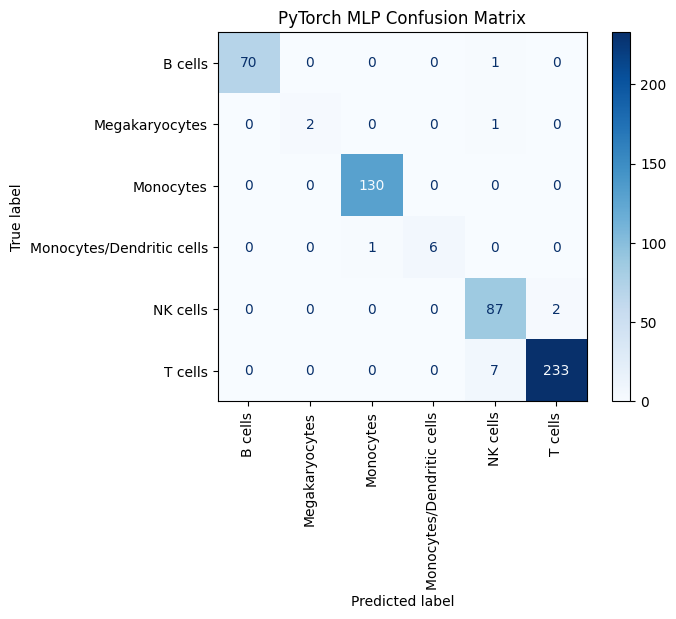

In [38]:
y_pred_idx = model.predict(X_test_tensor)
y_pred = [cell_types[i] for i in y_pred_idx]

print("=== PyTorch MLP Classification Report ===")
print(classification_report(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Weighted F1-score:", f1_score(y_test, y_pred, average='weighted'))

cm = confusion_matrix(y_test, y_pred, labels=cell_types)
ConfusionMatrixDisplay(cm, display_labels=cell_types).plot(cmap=plt.cm.Blues)
plt.xticks(rotation=90)
plt.title("PyTorch MLP Confusion Matrix")
plt.show()

In [68]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd

# Collect predictions from your models
# y_pred_logreg = best_logreg.predict(X_test)
y_pred_rf = best_rf.predict(X_test)
y_pred_mlp = [cell_types[i] for i in model.predict(X_test_tensor)]


# Compute metrics
results = {
    # "Logistic Regression": {
    #     "Accuracy": accuracy_score(y_test, y_pred_logreg),
    #     "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_logreg),
    #     "F1 (weighted)": f1_score(y_test, y_pred_logreg, average="weighted"),
    #     "Precision (weighted)": precision_score(y_test, y_pred_logreg, average="weighted"),
    #     "Recall (weighted)": recall_score(y_test, y_pred_logreg, average="weighted"),
    # },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_rf),
        "F1 (weighted)": f1_score(y_test, y_pred_rf, average="weighted"),
        "Precision (weighted)": precision_score(y_test, y_pred_rf, average="weighted"),
        "Recall (weighted)": recall_score(y_test, y_pred_rf, average="weighted"),
    },
    "MLP": {
        "Accuracy": accuracy_score(y_test, y_pred_mlp),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_mlp),
        "F1 (weighted)": f1_score(y_test, y_pred_mlp, average="weighted"),
        "Precision (weighted)": precision_score(y_test, y_pred_mlp, average="weighted"),
        "Recall (weighted)": recall_score(y_test, y_pred_mlp, average="weighted"),
    },
    "XGBoost": {
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_xgb),
        "F1 (weighted)": f1_score(y_test, y_pred_xgb, average="weighted"),
        "Precision (weighted)": precision_score(y_test, y_pred_xgb, average="weighted"),
        "Recall (weighted)": recall_score(y_test, y_pred_xgb, average="weighted"),
    },
    "SVM": {
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_svm),
        "F1 (weighted)": f1_score(y_test, y_pred_svm, average="weighted"),
        "Precision (weighted)": precision_score(y_test, y_pred_svm, average="weighted"),
        "Recall (weighted)": recall_score(y_test, y_pred_svm, average="weighted"),
    }
}

# Create DataFrame for nice display
results_df = pd.DataFrame(results).T
display(results_df.round(3))

,Accuracy,Balanced accuracy,F1 (weighted),Precision (weighted),Recall (weighted)
Random Forest,0.961,0.843,0.961,0.963,0.961
MLP,0.978,0.910,0.978,0.979,0.978
XGBoost,0.959,0.864,0.959,0.961,0.959
SVM,0.970,0.703,0.965,0.965,0.970


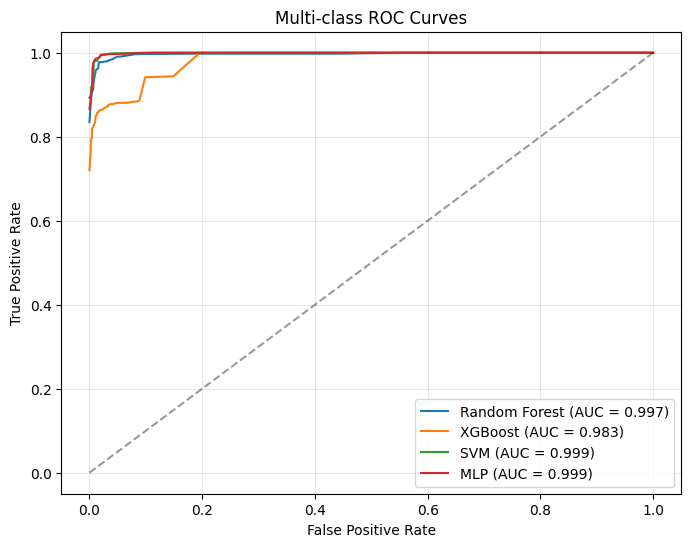

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# -------------------------------------
# 1. Prepare y for multiclass ROC
# -------------------------------------
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# -------------------------------------
# 2. Get prediction probabilities for each model
# -------------------------------------

# Random Forest
prob_rf = best_rf.predict_proba(X_test)

# XGBoost
prob_xgb = xgb_best.predict_proba(X_test)

# SVM — requires decision_function
if hasattr(svm_best, "predict_proba"):
    prob_svm = svm_best.predict_proba(X_test)
else:
    # Normalize decision_function output to [0,1]
    df_svm = svm_best.decision_function(X_test)
    prob_svm = (df_svm - df_svm.min()) / (df_svm.max() - df_svm.min())

# PyTorch MLP
with torch.no_grad():
    prob_mlp = model(X_test_tensor).softmax(dim=1).cpu().numpy()

# -------------------------------------
# 3. Dictionary for easy looping
# -------------------------------------
model_probs = {
    "Random Forest": prob_rf,
    "XGBoost": prob_xgb,
    "SVM": prob_svm,
    "MLP": prob_mlp,
}

# -------------------------------------
# 4. Plot ROC curves (macro-averaged)
# -------------------------------------
plt.figure(figsize=(8, 6))

for name, probs in model_probs.items():
    # Compute macro-average ROC
    fpr_list = []
    tpr_list = []
    auc_list = []

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        fpr_list.append(fpr)
        tpr_list.append(tpr)
        auc_list.append(auc(fpr, tpr))

    # Aggregate macro-average
    all_fpr = np.unique(np.concatenate([f for f in fpr_list]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_list[i], tpr_list[i])

    mean_tpr /= n_classes
    roc_auc = auc(all_fpr, mean_tpr)

    plt.plot(all_fpr, mean_tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# -------------------------------------
# 5. Plot formatting
# -------------------------------------
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.show()
